In [3]:
#data collection (kaggle).
#preprocessing
#model implementation
#training
#testing
#evaluation
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

BASE_DIR = r"C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)


Train dir: C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI\train
Val dir: C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI\validation



Image counts:
        split    class  count
0       train  Healthy    700
1       train     Sick    700
2  validation  Healthy     40
3  validation     Sick     40


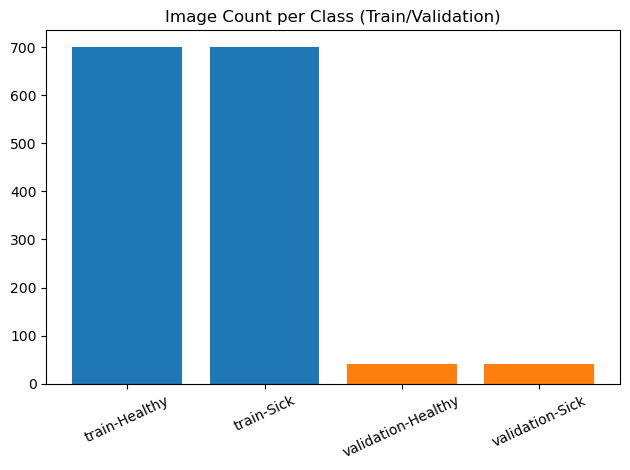

In [5]:
def count_images_by_class(root_dir):
    data = []
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue

        patterns = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
        files = []
        for p in patterns:
            files.extend(glob.glob(os.path.join(cls_path, p)))
        data.append({"split": os.path.basename(root_dir), "class": cls, "count": len(files)})
    return pd.DataFrame(data)

train_counts = count_images_by_class(TRAIN_DIR)
val_counts   = count_images_by_class(VAL_DIR)

counts_df = pd.concat([train_counts, val_counts], ignore_index=True)
print("\nImage counts:")
print(counts_df)

# Plot counts
plt.figure()
for split in counts_df["split"].unique():
    sub = counts_df[counts_df["split"] == split]
    plt.bar([f"{split}-{c}" for c in sub["class"]], sub["count"])
plt.title("Image Count per Class (Train/Validation)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

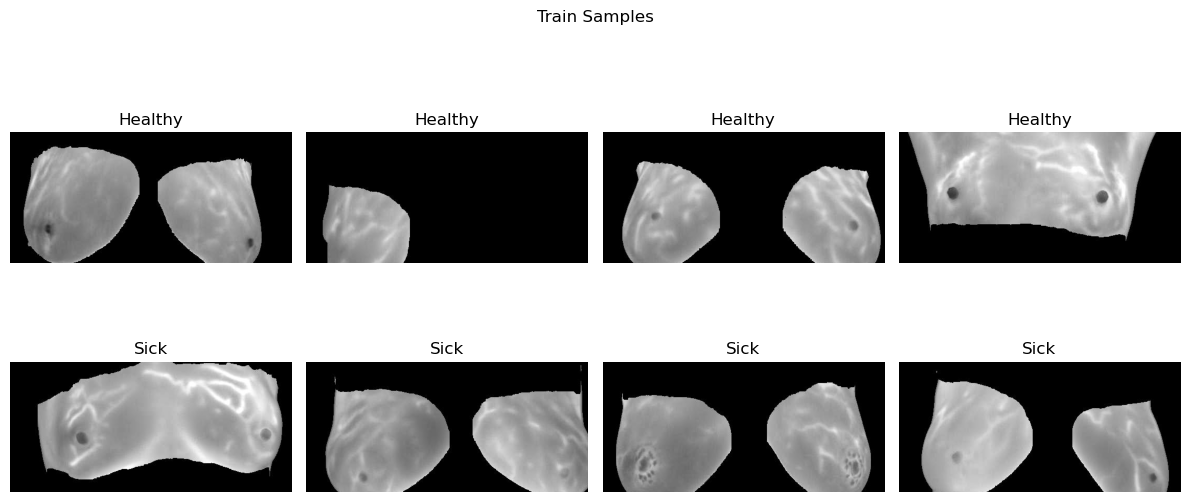

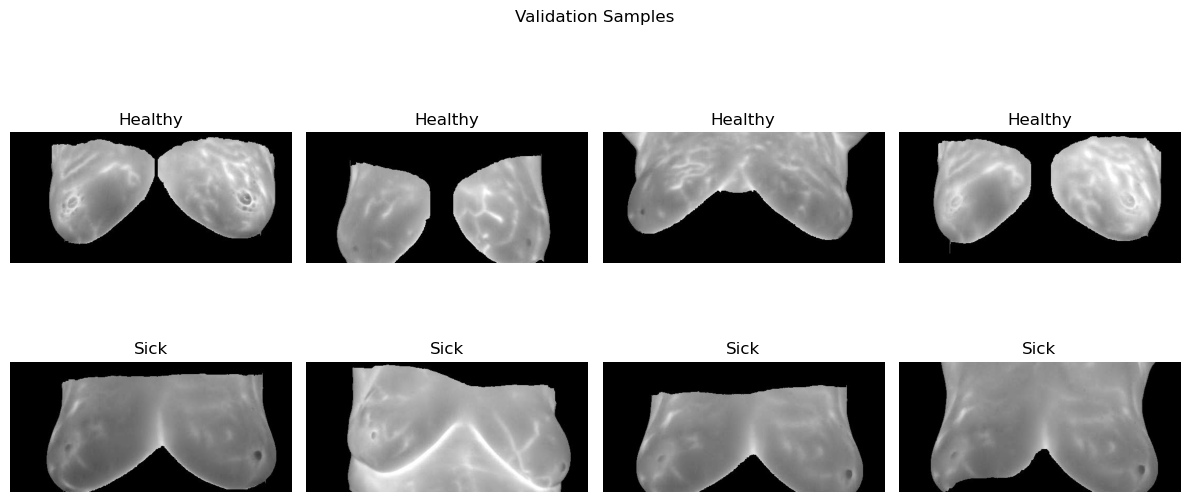

In [6]:
def get_some_images(dir_path, class_name, n=6):
    cls_path = os.path.join(dir_path, class_name)
    patterns = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for p in patterns:
        files.extend(glob.glob(os.path.join(cls_path, p)))
    if len(files) == 0:
        return []
    return random.sample(files, min(n, len(files)))

def show_samples(split_dir, title):
    classes = [d for d in sorted(os.listdir(split_dir)) if os.path.isdir(os.path.join(split_dir, d))]
    plt.figure(figsize=(12, 6))
    idx = 1
    for cls in classes:
        samples = get_some_images(split_dir, cls, n=4)
        for f in samples:
            img = Image.open(f).convert("RGB")
            plt.subplot(len(classes), 4, idx)
            plt.imshow(img)
            plt.axis("off")
            plt.title(cls)
            idx += 1
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, "Train Samples")
show_samples(VAL_DIR, "Validation Samples")

In [8]:
IMG_SIZE = (224, 224)  
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",  # 0/1
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("\nClass names:", class_names) 


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 1400 files belonging to 2 classes.
Found 80 files belonging to 2 classes.

Class names: ['Healthy', 'Sick']


In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # binary classification
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,811,201 (25.98 MB)

 Trainable params: 6,811,201 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 46s 518ms/step - accuracy: 0.5517 - auc: 0.5617 - loss: 0.6884 - val_accuracy: 0.7000 - val_auc: 0.8597 - val_loss: 0.6017 - learning_rate: 1.0000e-04
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 505ms/step - accuracy: 0.5784 - auc: 0.6209 - loss: 0.6699 - val_accuracy: 0.7125 - val_auc: 0.7231 - val_loss: 0.5923 - learning_rate: 1.0000e-04
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 509ms/step - accuracy: 0.6475 - auc: 0.7038 - loss: 0.6271 - val_accuracy: 0.6375 - val_auc: 0.7750 - val_loss: 0.6026 - learning_rate: 1.0000e-04
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 512ms/step - accuracy: 0.6682 - auc: 0.7320 - loss: 0.6062 - val_accuracy: 0.6625 - val_auc: 0.6850 - val_loss: 0.6699 - learning_rate: 1.0000e-04
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - accuracy: 0.6879 - auc: 0.7667 - loss: 0.5722 - val_accuracy: 0.5125 - val_auc: 0.5919 - val_loss: 0.7831 - learning_rate: 5.0000e-05
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 385ms/step - 

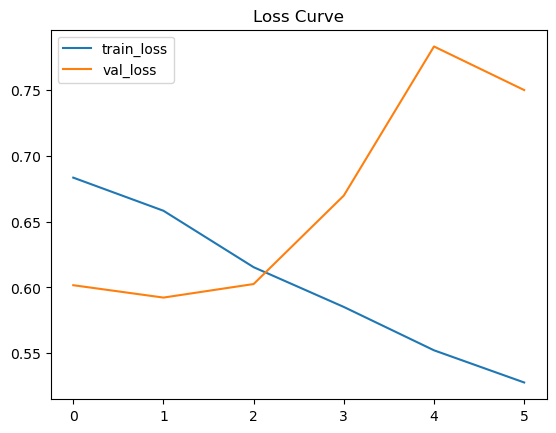

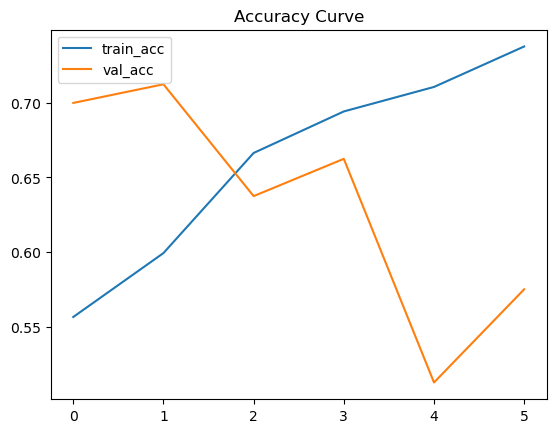

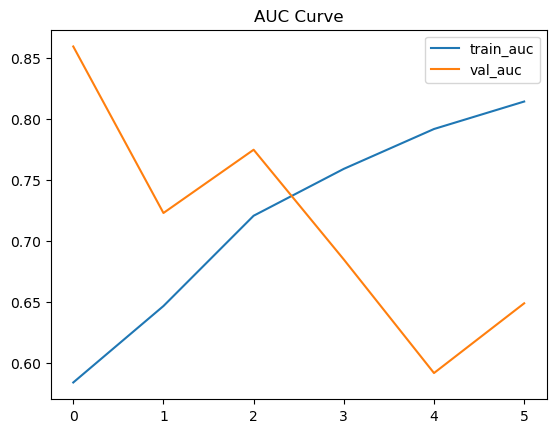


Confusion Matrix:
 [[17 23]
 [ 1 39]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.42      0.59        40
        Sick       0.63      0.97      0.76        40

    accuracy                           0.70        80
   macro avg       0.79      0.70      0.68        80
weighted avg       0.79      0.70      0.68        80



In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=5, mode="max", restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


hist = pd.DataFrame(history.history)

plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["auc"], label="train_auc")
plt.plot(hist["val_auc"], label="val_auc")
plt.title("AUC Curve")
plt.legend()
plt.show()

y_true = []
y_pred = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    y_pred.extend(preds.tolist())
    y_true.extend(labels.numpy().astype(int).ravel().tolist())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as res_preprocess


BASE_DIR = r"C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 15
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


def build_fusion_attention_model(input_shape=(224, 224, 3), num_classes=2):
    inputs = layers.Input(shape=input_shape)

   
    x = layers.Lambda(lambda img: tf.image.grayscale_to_rgb(img) if img.shape[-1] == 1 else img)(inputs)

   
    x_aug = data_augmentation(x)

    
    x1 = layers.Lambda(eff_preprocess, name="eff_preprocess")(x_aug)
    x2 = layers.Lambda(res_preprocess, name="res_preprocess")(x_aug)

   
    backbone1 = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x1
    )
    backbone1.trainable = False

    feat1 = layers.GlobalAveragePooling2D()(backbone1.output)
    feat1 = layers.Dense(256, activation="relu")(feat1)
    feat1 = layers.Dropout(0.3)(feat1)

 
    backbone2 = ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=x2
    )
    backbone2.trainable = False

    feat2 = layers.GlobalAveragePooling2D()(backbone2.output)
    feat2 = layers.Dense(256, activation="relu")(feat2)
    feat2 = layers.Dropout(0.3)(feat2)

   
    fused = layers.Concatenate(name="feature_fusion")([feat1, feat2])  # 512 dims

 
    attention = layers.Dense(256, activation="relu")(fused)
    attention = layers.Dense(512, activation="sigmoid", name="attention_weights")(attention)

    attended_features = layers.Multiply(name="attended_fusion")([fused, attention])

   
    x = layers.Dense(256, activation="relu")(attended_features)
    x = layers.Dropout(0.4)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    else:
        outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Fusion_Attention_Model")
    return model

model = build_fusion_attention_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

model.summary()


if num_classes == 2:
    loss_fn = "binary_crossentropy"
    metrics = ["accuracy", tf.keras.metrics.AUC(name="auc")]
else:
    loss_fn = "sparse_categorical_crossentropy"
    metrics = ["accuracy"]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics
)


callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_fusion_attention_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


results = model.evaluate(val_ds, verbose=1)
print("Validation results:", results)


model.save("final_fusion_attention_model.keras")
print("Model saved successfully.")

Train dir: C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI\train
Val dir: C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI\validation
Found 1400 files belonging to 2 classes.
Found 80 files belonging to 2 classes.
Classes: ['Healthy', 'Sick']
Number of classes: 2



Model: "Fusion_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation             │ (None, 224, 224, 3)       │               0 │ lambda[0][0]               │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ eff_preprocess (Lambda)       │ (None, 224, 224, 3)       │               0 │ data_augmentation[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ eff_preprocess[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │               

 Total params: 28,884,260 (110.18 MB)

 Trainable params: 1,246,977 (4.76 MB)

 Non-trainable params: 27,637,283 (105.43 MB)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.5410 - auc: 0.5746 - loss: 0.6995
Epoch 1: val_accuracy improved from -inf to 0.58750, saving model to best_fusion_attention_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 100s 932ms/step - accuracy: 0.5414 - auc: 0.5751 - loss: 0.6992 - val_accuracy: 0.5875 - val_auc: 0.6413 - val_loss: 0.6852 - learning_rate: 1.0000e-04
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.6665 - auc: 0.7434 - loss: 0.5995
Epoch 2: val_accuracy did not improve from 0.58750
88/88 ━━━━━━━━━━━━━━━━━━━━ 76s 863ms/step - accuracy: 0.6667 - auc: 0.7437 - loss: 0.5992 - val_accuracy: 0.5875 - val_auc: 0.5497 - val_loss: 0.7751 - learning_rate: 1.0000e-04
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.7436 - auc: 0.8253 - loss: 0.5282
Epoch 3: val_accuracy did not improve from 0.58750

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
88/88 ━━━━━━━━━━━━━━━━━━━━ 76s 857ms/step - accuracy: 0.7437 

Train dir: C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI\train
Val dir: C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI\validation
Found 1400 files belonging to 2 classes.
Found 80 files belonging to 2 classes.
Classes: ['Healthy', 'Sick']
Number of classes: 2



Model: "Gated_Bilinear_Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation             │ (None, 224, 224, 3)       │               0 │ lambda[0][0]               │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ eff_preprocess (Lambda)       │ (None, 224, 224, 3)       │               0 │ data_augmentation[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ eff_preprocess[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │               

 Total params: 28,953,124 (110.45 MB)

 Trainable params: 1,314,305 (5.01 MB)

 Non-trainable params: 27,638,819 (105.43 MB)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.5394 - auc: 0.5626 - loss: 0.8287 - precision: 0.5508 - recall: 0.3762
Epoch 1: val_accuracy improved from -inf to 0.48750, saving model to best_gated_bilinear_fusion_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 91s 853ms/step - accuracy: 0.5398 - auc: 0.5631 - loss: 0.8280 - precision: 0.5514 - recall: 0.3770 - val_accuracy: 0.4875 - val_auc: 0.4100 - val_loss: 0.7039 - val_precision: 0.4925 - val_recall: 0.8250 - learning_rate: 1.0000e-04
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.6282 - auc: 0.6692 - loss: 0.7077 - precision: 0.6372 - recall: 0.5984
Epoch 2: val_accuracy improved from 0.48750 to 0.51250, saving model to best_gated_bilinear_fusion_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 73s 826ms/step - accuracy: 0.6283 - auc: 0.6694 - loss: 0.7075 - precision: 0.6373 - recall: 0.5986 - val_accuracy: 0.5125 - val_auc: 0.6359 - val_loss: 0.6901 - val_precision: 0.5070 - val_recall: 0.9000 - learning_rate

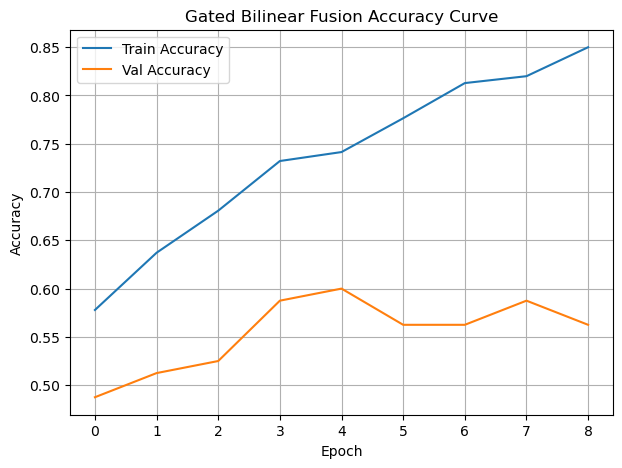

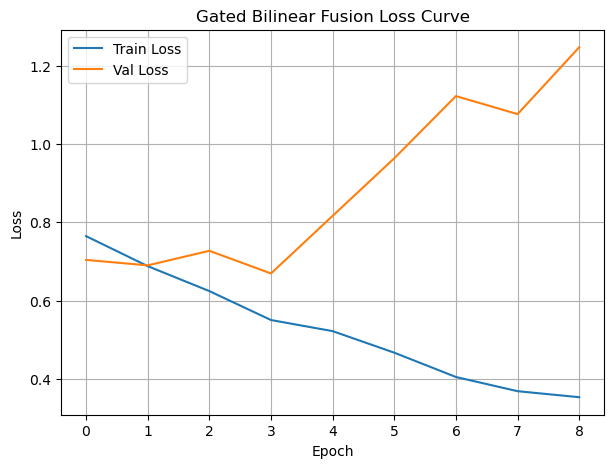

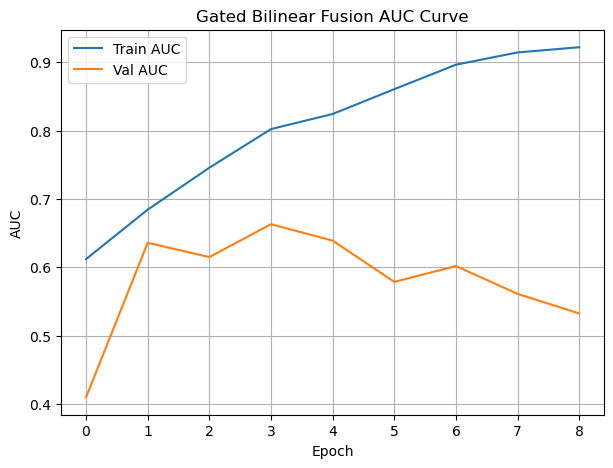

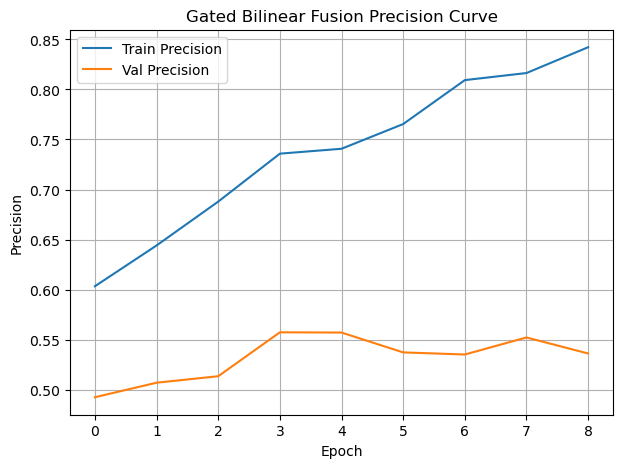

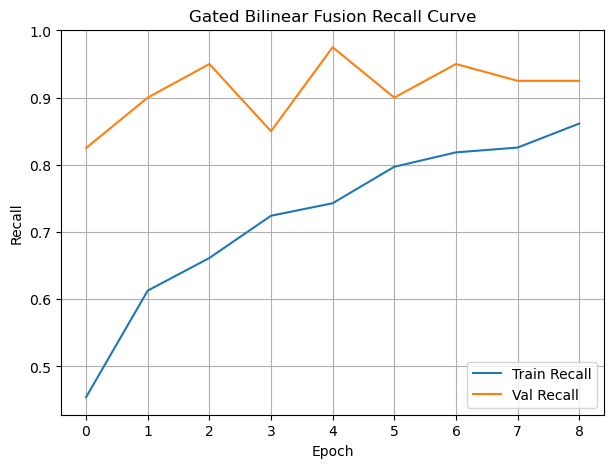

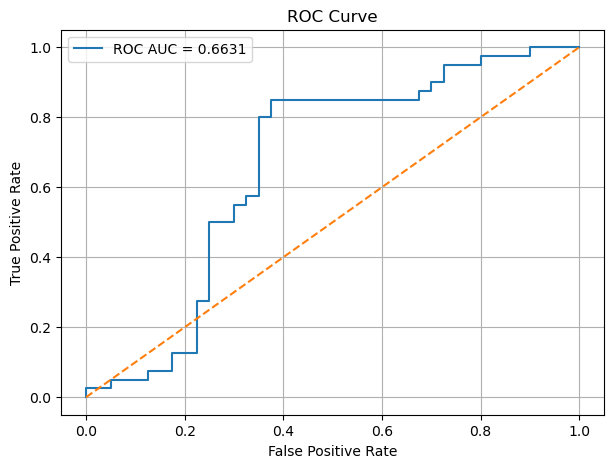

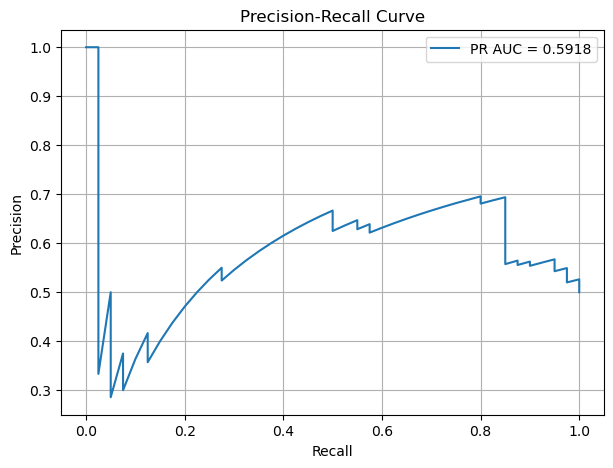

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as res_preprocess

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


BASE_DIR = r"C:\Users\MrLaptop\Desktop\react\Breast Cancer Patients MRI"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 15
SEED = 42

print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


class GatedBilinearFusion(layers.Layer):
    def __init__(self, units=256, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate

        self.proj1 = layers.Dense(units, activation="relu")
        self.proj2 = layers.Dense(units, activation="relu")

        self.gate1 = layers.Dense(units, activation="sigmoid")
        self.gate2 = layers.Dense(units, activation="sigmoid")

        self.bn = layers.BatchNormalization()
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        f1, f2 = inputs

        p1 = self.proj1(f1)
        p2 = self.proj2(f2)

        g1 = self.gate1(f2)   # branch 2 gates branch 1
        g2 = self.gate2(f1)   # branch 1 gates branch 2

        gated1 = p1 * g1
        gated2 = p2 * g2

        bilinear = gated1 * gated2
        fused = tf.concat([gated1, gated2, bilinear], axis=-1)

        fused = self.bn(fused, training=training)
        fused = self.dropout(fused, training=training)
        return fused


def build_gated_bilinear_fusion_model(input_shape=(224, 224, 3), num_classes=2):
    inputs = layers.Input(shape=input_shape)

    x = layers.Lambda(
        lambda img: tf.image.grayscale_to_rgb(img) if img.shape[-1] == 1 else img
    )(inputs)

    x_aug = data_augmentation(x)

    x1 = layers.Lambda(eff_preprocess, name="eff_preprocess")(x_aug)
    x2 = layers.Lambda(res_preprocess, name="res_preprocess")(x_aug)

    # Backbone 1
    backbone1 = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x1
    )
    backbone1.trainable = False

    feat1 = layers.GlobalAveragePooling2D()(backbone1.output)
    feat1 = layers.Dense(256, activation="relu")(feat1)
    feat1 = layers.Dropout(0.3)(feat1)

    # Backbone 2
    backbone2 = ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=x2
    )
    backbone2.trainable = False

    feat2 = layers.GlobalAveragePooling2D()(backbone2.output)
    feat2 = layers.Dense(256, activation="relu")(feat2)
    feat2 = layers.Dropout(0.3)(feat2)

    # Gated Bilinear Fusion
    fused = GatedBilinearFusion(units=256, dropout_rate=0.3)([feat1, feat2])

    x = layers.Dense(256, activation="relu")(fused)
    x = layers.Dropout(0.4)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    else:
        outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="Gated_Bilinear_Fusion_Model")
    return model

model2 = build_gated_bilinear_fusion_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

model2.summary()


if num_classes == 2:
    loss_fn = "binary_crossentropy"
    metrics = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
else:
    loss_fn = "sparse_categorical_crossentropy"
    metrics = ["accuracy"]

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics
)


callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_gated_bilinear_fusion_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]


history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


results2 = model2.evaluate(val_ds, verbose=1)
print("Validation results:", results2)

model2.save("final_gated_bilinear_fusion_model.keras")
print("Model saved successfully.")

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

y_prob = model2.predict(val_ds)

if num_classes == 2:
    y_prob = y_prob.ravel()
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)


print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


def plot_training_curves(history, model_name="Model"):
    history_dict = history.history

    # Accuracy
    plt.figure(figsize=(7,5))
    plt.plot(history_dict["accuracy"], label="Train Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(7,5))
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # AUC
    if "auc" in history_dict and "val_auc" in history_dict:
        plt.figure(figsize=(7,5))
        plt.plot(history_dict["auc"], label="Train AUC")
        plt.plot(history_dict["val_auc"], label="Val AUC")
        plt.title(f"{model_name} AUC Curve")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Precision
    if "precision" in history_dict and "val_precision" in history_dict:
        plt.figure(figsize=(7,5))
        plt.plot(history_dict["precision"], label="Train Precision")
        plt.plot(history_dict["val_precision"], label="Val Precision")
        plt.title(f"{model_name} Precision Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Precision")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Recall
    if "recall" in history_dict and "val_recall" in history_dict:
        plt.figure(figsize=(7,5))
        plt.plot(history_dict["recall"], label="Train Recall")
        plt.plot(history_dict["val_recall"], label="Val Recall")
        plt.title(f"{model_name} Recall Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Recall")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_training_curves(history2, "Gated Bilinear Fusion")


if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


if num_classes == 2:
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(7,5))
    plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.4f}")
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.show()